# Image Processing for Facial Recognition
## Objective

The objective of this notebook is to preprocess face images collected from all group members by:
- Loading the images
- Displaying sample images
- Applying image augmentation techniques
- Extracting histogram features
- Saving the extracted features for later use in facial recognition.

In [ ]:
import os
import cv2
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

## Load Face Images

In [ ]:
# List to store image names and image data
images = []

# Common image file extensions
image_extensions = ('.jpg', '.jpeg', '.png')

# Loop through all uploaded files
for file in os.listdir():
    if file.lower().endswith(image_extensions):
        image = cv2.imread(file)

        # Convert from BGR (OpenCV default) to RGB
        image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

        # Store filename and image
        images.append((file, image))

print(f"Successfully loaded {len(images)} images.")

Successfully loaded 12 images.


## Display Sample Images

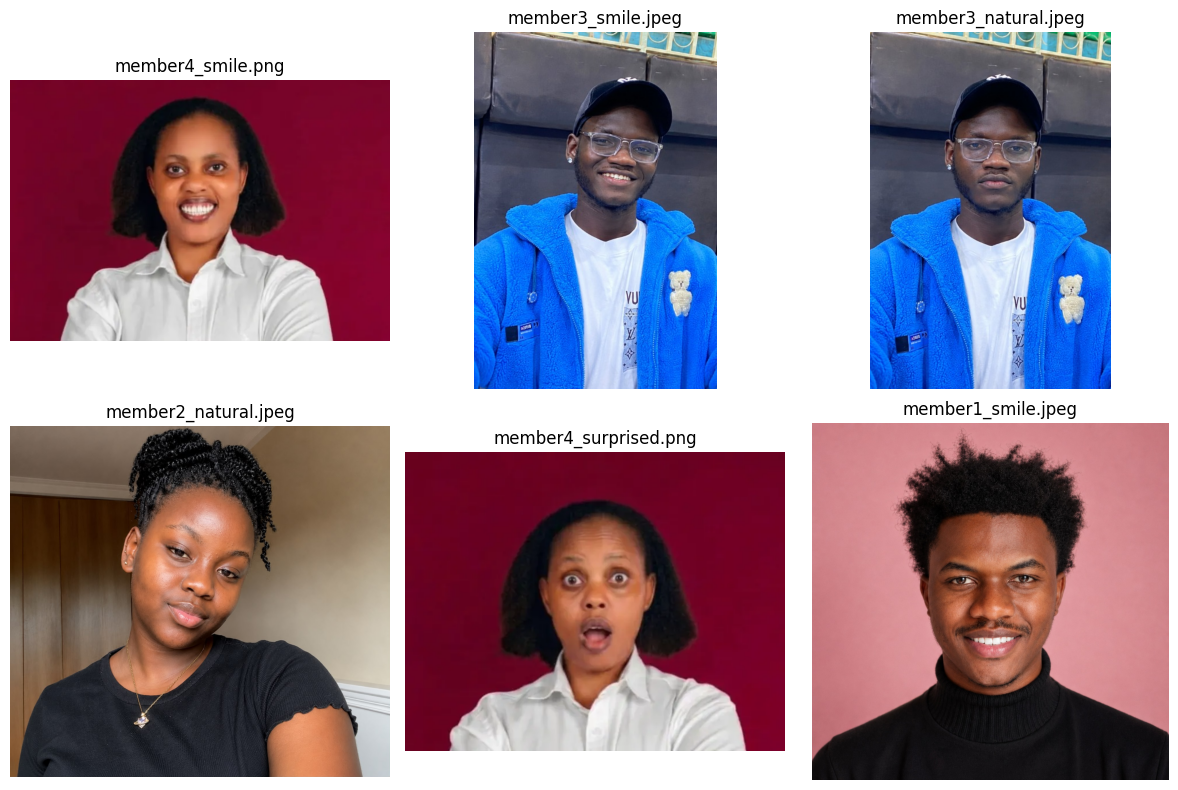

In [ ]:
# Display the first 6 images
plt.figure(figsize=(12, 8))

for i, (filename, image) in enumerate(images[:6]):
    plt.subplot(2, 3, i + 1)
    plt.imshow(image)
    plt.title(filename)
    plt.axis('off')

plt.tight_layout()
plt.show()

## Image Augmentation

In [ ]:
# Rotate an image
def rotate_image(image, angle=15):
    height, width = image.shape[:2]
    center = (width // 2, height // 2)

    rotation_matrix = cv2.getRotationMatrix2D(center, angle, 1.0)
    rotated = cv2.warpAffine(image, rotation_matrix, (width, height))

    return rotated


# Flip an image horizontally
def flip_image(image):
    return cv2.flip(image, 1)


# Convert an image to grayscale
def grayscale_image(image):
    return cv2.cvtColor(image, cv2.COLOR_RGB2GRAY)

In [ ]:
# Select the first image
filename, original = images[0]

# Apply augmentations
rotated = rotate_image(original)
flipped = flip_image(original)
gray = grayscale_image(original)

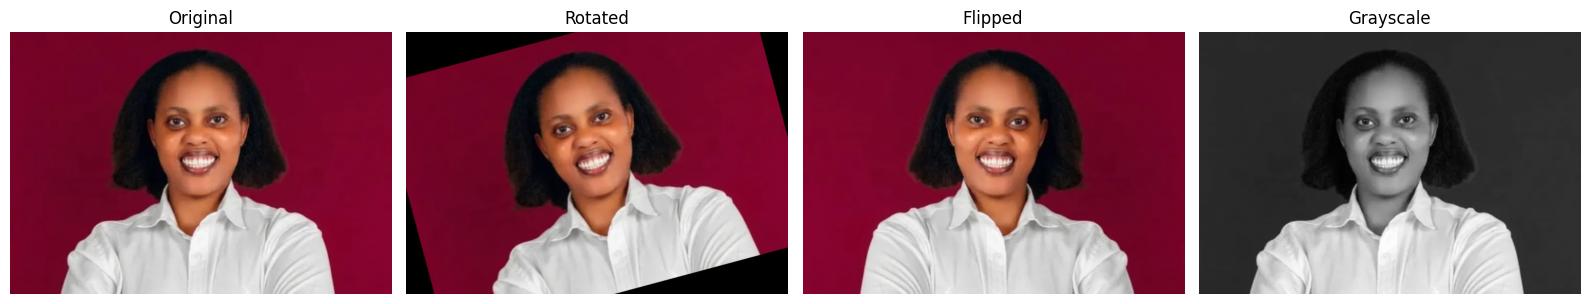

In [ ]:
plt.figure(figsize=(16, 4))

# Original
plt.subplot(1, 4, 1)
plt.imshow(original)
plt.title("Original")
plt.axis("off")

# Rotated
plt.subplot(1, 4, 2)
plt.imshow(rotated)
plt.title("Rotated")
plt.axis("off")

# Flipped
plt.subplot(1, 4, 3)
plt.imshow(flipped)
plt.title("Flipped")
plt.axis("off")

# Grayscale
plt.subplot(1, 4, 4)
plt.imshow(gray, cmap="gray")
plt.title("Grayscale")
plt.axis("off")

plt.tight_layout()
plt.show()

In [ ]:
def extract_histogram(image):
    """
    Extract a normalized grayscale histogram with 256 bins.
    """
    histogram = cv2.calcHist([image], [0], None, [256], [0, 256])

    # Normalize the histogram
    histogram = cv2.normalize(histogram, histogram)

    return histogram.flatten()

In [ ]:
feature_data = []

for filename, image in images:

    # Convert image to grayscale
    gray = grayscale_image(image)

    # Extract histogram features
    histogram = extract_histogram(gray)

    # Store filename + histogram values
    row = [filename] + histogram.tolist()

    feature_data.append(row)

print(f"Extracted features from {len(feature_data)} images.")

Extracted features from 12 images.


In [ ]:
columns = ["filename"] + [f"histogram_bin_{i}" for i in range(256)]

image_features_df = pd.DataFrame(feature_data, columns=columns)

image_features_df.head()

,filename,histogram_bin_0,histogram_bin_1,histogram_bin_2,histogram_bin_3,histogram_bin_4,histogram_bin_5,histogram_bin_6,histogram_bin_7,histogram_bin_8,...,histogram_bin_246,histogram_bin_247,histogram_bin_248,histogram_bin_249,histogram_bin_250,histogram_bin_251,histogram_bin_252,histogram_bin_253,histogram_bin_254,histogram_bin_255
0,member4_smile.png,0.000000,0.000013,0.000241,0.003900,0.010574,0.018337,0.013385,0.013094,0.016083,...,0.004686,0.002355,0.000608,0.000127,0.000000,0.000000,0.000000,0.000000,0.000000,0.0
1,member3_smile.jpeg,0.000272,0.007666,0.063080,0.084716,0.050355,0.029263,0.020430,0.015177,0.012569,...,0.002335,0.001790,0.001245,0.000895,0.000856,0.000389,0.000156,0.000272,0.000156,0.0
2,member3_natural.jpeg,0.000157,0.004093,0.043133,0.091776,0.049194,0.024400,0.017356,0.014876,0.011531,...,0.003581,0.002165,0.002007,0.000984,0.000945,0.000630,0.000197,0.000197,0.000394,0.0
3,member2_natural.jpeg,0.090492,0.051684,0.035938,0.031636,0.028743,0.025713,0.023426,0.021760,0.020169,...,0.000212,0.000167,0.000091,0.000098,0.000182,0.000189,0.000144,0.000061,0.000023,0.0
4,member4_surprised.png,0.000000,0.000000,0.000012,0.000037,0.000305,0.000427,0.003380,0.011506,0.017827,...,0.001598,0.000427,0.000159,0.000000,0.000000,0.000024,0.000000,0.000000,0.000000,0.0


In [ ]:
image_features_df.to_csv("image_features.csv", index=False)

print("image_features.csv has been saved successfully!")

image_features.csv has been saved successfully!
